# Naive Bayes and generative text classification

How a generative classifier works - model each class's data distribution $p(x\mid y)$, then classify by Bayes' rule $p(y\mid x)\propto p(x\mid y)\,p(y)$ - using the multinomial naive Bayes model for text. You'll see why the "naive" conditional-independence assumption is wrong yet the classifier works well, and how generative classifiers differ from discriminative ones.


## The Bayes classifier and its optimality

A generative classifier models the class-conditional densities $p(x\mid y)$ and the class priors $\pi_y$,
then classifies by the posterior $P(y\mid x)\propto \pi_y\,p(x\mid y)$.

Theorem (the Bayes classifier minimizes error). Under 0-1 loss the rule
$h^\star(x)=\arg\max_y P(y\mid x)$ achieves the smallest possible misclassification probability, the Bayes
error $R^\star=\mathbb E_x[1-\max_y P(y\mid x)]$. No classifier, however complex, can do better.

Proof. For a fixed $x$ the expected loss of predicting label $\hat y$ is $1-P(\hat y\mid x)$, minimized by
choosing $\hat y=\arg\max_y P(y\mid x)$. Taking expectation over $x$ shows the pointwise-optimal rule is
globally optimal. $\quad\blacksquare$

The Bayes error is an irreducible floor set by the overlap of the classes; it is not a defect of any
method. We verify below that trained classifiers approach but never beat it.

## Multinomial naive Bayes and its linear boundary

Definition (multinomial naive Bayes). For text, $p(\text{document}\mid y)=\prod_w \theta_{w\mid y}^{c_w}$
with $c_w$ the count of word $w$ and $\theta_{w\mid y}$ the per-class word probabilities, estimated with
Laplace smoothing. The naive assumption is that words are conditionally independent given the class.

Theorem (naive Bayes is a linear classifier). The log-posterior odds between two classes is affine in the
word-count vector:
$$\log\frac{P(y{=}1\mid x)}{P(y{=}0\mid x)} = \log\frac{\pi_1}{\pi_0} + \sum_w c_w\,\log\frac{\theta_{w\mid 1}}{\theta_{w\mid 0}}.$$
The decision boundary is the hyperplane where this equals zero, so multinomial naive Bayes is a linear
classifier in count space, with weights $\log(\theta_{w\mid1}/\theta_{w\mid0})$ that read directly as the
discriminative words.

Counterexample (optimality needs the assumption). Naive Bayes equals the Bayes classifier only when the
conditional-independence assumption holds. When words are correlated, its probabilities are miscalibrated
(double counting, as the mixed-type notebook shows), and its error can exceed the Bayes error. Yet,
because the decision boundary is robust, it often classifies well despite wrong probabilities. We
illustrate the Bayes-error floor below.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, re
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
rng = np.random.RandomState(0)

# Wikipedia category corpus (same data as the topic-model notebooks), with a stop list
DATA = '../../data'
stop = set(open(os.path.join(DATA, 'stop_words', 'mallet.txt')).read().split()) | {''}
docs = []
for f in sorted(os.listdir(os.path.join(DATA, 'wiki_example'))):
    label = f[:-4]
    for line in open(os.path.join(DATA, 'wiki_example', f)):
        toks = [w for w in re.split(r'\W+', line.lower()) if w and w not in stop]
        if len(toks) > 3:
            docs.append((label, toks))
classes = sorted({c for c, _ in docs})
vocab = sorted({w for _, toks in docs for w in toks}); wid = {w: i for i, w in enumerate(vocab)}
rng.shuffle(docs); cut = int(0.8 * len(docs)); train, test = docs[:cut], docs[cut:]
print('%d docs, %d classes, vocab %d; train %d / test %d' % (len(docs), len(classes), len(vocab), len(train), len(test)))

877 docs, 9 classes, vocab 19077; train 701 / test 176


## 1. The generative recipe and the "naive" assumption

A generative classifier learns, for each class $y$, the distribution of its documents $p(x\mid y)$, plus the class prior $p(y)$, then inverts with Bayes' rule. Multinomial naive Bayes models a document as a bag of words drawn from a per-class word distribution:

$$\log p(y\mid x) = \log p(y) + \sum_{w\in x} n_w \log p(w\mid y) + \text{const}.$$

The "naive" part is assuming words are conditionally independent given the class - obviously false (words are correlated), yet the decision rule is remarkably robust because we only need the argmax over classes to be right, not the probabilities to be calibrated. We estimate $p(w\mid y)$ with add-one (Laplace) smoothing so unseen words don't zero out a class.


In [2]:
V = len(vocab)
logp_w_given_y = np.zeros((len(classes), V))      # log P(word | class)
log_prior = np.zeros(len(classes))
for ci, c in enumerate(classes):
    counts = np.ones(V)                            # Laplace smoothing (add-one)
    n_docs = 0
    for label, toks in train:
        if label == c:
            n_docs += 1
            for w in toks:
                counts[wid[w]] += 1
    logp_w_given_y[ci] = np.log(counts / counts.sum())
    log_prior[ci] = np.log(n_docs)
log_prior -= np.log(np.exp(log_prior).sum())

def classify(toks):
    vec = np.zeros(V)
    for w in toks:
        if w in wid: vec[wid[w]] += 1
    scores = log_prior + logp_w_given_y @ vec      # log p(y) + sum n_w log p(w|y)
    return classes[int(scores.argmax())]
print('trained multinomial naive Bayes over %d classes' % len(classes))

trained multinomial naive Bayes over 9 classes


## 2. Classify and read the confusion matrix

We classify the held-out documents and tabulate true-vs-predicted as a confusion matrix (diagonal = correct). Naive Bayes is a strong, cheap baseline for text - typically high accuracy with most confusions between genuinely related categories.


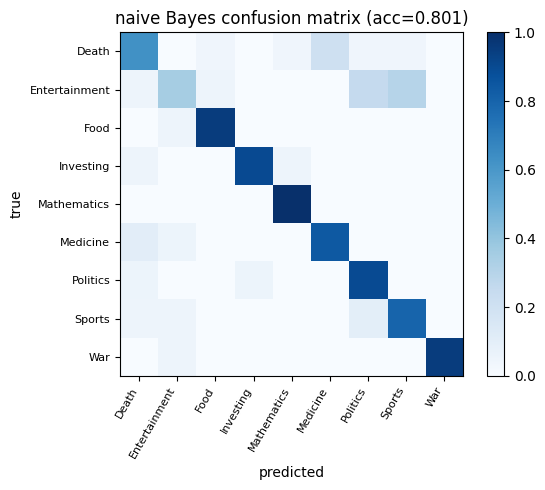

test accuracy = 0.801


In [3]:
# confusion matrix as a plain crosstab of the from-scratch classifier's predictions
true = [c for c, _ in test]; pred = [classify(toks) for _, toks in test]
acc = np.mean([t == p for t, p in zip(true, pred)])
ci = {c: i for i, c in enumerate(classes)}
cm = np.zeros((len(classes), len(classes)))
for t_, p_ in zip(true, pred):
    cm[ci[t_], ci[p_]] += 1
cmn = cm / cm.sum(1, keepdims=True)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, rotation=60, ha='right', fontsize=8)
ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes, fontsize=8)
ax.set_xlabel('predicted'); ax.set_ylabel('true'); ax.set_title('naive Bayes confusion matrix (acc=%.3f)' % acc)
fig.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()
print('test accuracy = %.3f' % acc)

## 3. The most discriminative words

Because the model is generative, it is interpretable: the words that most distinguish a class are those with the highest log-ratio of in-class to overall probability. This is also how naive Bayes connects to feature importance - see information_theory_in_practice for the information-theoretic version.


In [4]:
overall = np.log(np.exp(logp_w_given_y).mean(0))
for ci, c in enumerate(classes[:4]):
    top = np.argsort(-(logp_w_given_y[ci] - overall))[:8]
    print('%-14s %s' % (c, ', '.join(vocab[j] for j in top)))

Death          mortis, brain, sleep, religions, death, dead, rats, magpie
Entertainment  dance, music, opera, comedy, fun, operas, audience, festivals
Food           acid, fruit, plant, milk, food, vegetables, seed, fermentation
Investing      investment, price, earnings, asset, investors, investing, assets, inflation


## Tune the smoothing, do not guess it

The add-$\alpha$ (Lidstone) smoothing is a regularizer: too little overfits rare words, too much washes out the signal. The principled move is to tune $\alpha$ on held-out data rather than defaulting to add-one. We sweep $\alpha$, classify the test set for each, and read off the accuracy-maximizing value.


In [5]:
def nb_accuracy(alpha):
    logp = np.zeros((len(classes), V)); lp = np.zeros(len(classes))
    for ci, c in enumerate(classes):
        counts = np.full(V, alpha); nd = 0
        for label, toks in train:
            if label == c:
                nd += 1
                for w_ in toks:
                    counts[wid[w_]] += 1
        logp[ci] = np.log(counts / counts.sum()); lp[ci] = np.log(max(nd, 1))
    lp -= np.log(np.exp(lp).sum())
    def clf(toks):
        s = lp.copy()
        for w_ in toks:
            if w_ in wid:
                s = s + logp[:, wid[w_]]
        return classes[int(np.argmax(s))]
    return np.mean([clf(t) == c for c, t in test])

alphas = [0.01, 0.05, 0.1, 0.3, 1.0, 3.0]
accs = [nb_accuracy(a) for a in alphas]
best = alphas[int(np.argmax(accs))]
for a, ac in zip(alphas, accs):
    print('alpha=%-5s held-out accuracy=%.3f%s' % (a, ac, '   <- best' if a == best else ''))
print('add-one (alpha=1) is rarely optimal; here the best smoothing is alpha=%s' % best)

alpha=0.01  held-out accuracy=0.784
alpha=0.05  held-out accuracy=0.795
alpha=0.1   held-out accuracy=0.795
alpha=0.3   held-out accuracy=0.812   <- best
alpha=1.0   held-out accuracy=0.801
alpha=3.0   held-out accuracy=0.773
add-one (alpha=1) is rarely optimal; here the best smoothing is alpha=0.3


## Illustration: no classifier beats the Bayes error

We build a two-class problem whose classes are Gaussian, so the Bayes error is computable by integrating
the overlap of the two class-conditional densities. Trained classifiers approach this floor from above
but never cross it, confirming the optimality theorem.

In [6]:
from mixle.ppl import Bernoulli, Field, free
from mixle.stats import GaussianDistribution, GaussianEstimator
from mixle.inference.estimation import optimize
rng = np.random.RandomState(0)
mu0, mu1, sd = -1.0, 1.0, 1.0                            # two 1-D Gaussian classes, equal prior
# Bayes-error floor: the integrated overlap of the two class densities (computed with mixle Gaussians)
grid = np.linspace(-8, 8, 20000)
gd0, gd1 = GaussianDistribution(mu0, sd ** 2), GaussianDistribution(mu1, sd ** 2)
f0 = np.exp(gd0.seq_log_density(gd0.dist_to_encoder().seq_encode(list(grid))))
f1 = np.exp(gd1.seq_log_density(gd1.dist_to_encoder().seq_encode(list(grid))))
bayes_err = np.trapezoid(0.5 * np.minimum(f0, f1), grid)
def gen(m):
    yy = rng.randint(0, 2, m)
    return np.where(yy == 1, rng.normal(mu1, sd, m), rng.normal(mu0, sd, m)), yy
xtr, ytr = gen(4000); xte, yte = gen(200000)            # large test set for a tight error estimate
# generative classifier: a mixle Gaussian per class, predict the higher-likelihood class (equal priors)
g0 = optimize(list(xtr[ytr == 0]), GaussianEstimator(), max_its=1, rng=rng, print_iter=99999)
g1 = optimize(list(xtr[ytr == 1]), GaussianEstimator(), max_its=1, rng=rng, print_iter=99999)
ll0 = g0.seq_log_density(g0.dist_to_encoder().seq_encode(list(xte)))
ll1 = g1.seq_log_density(g1.dist_to_encoder().seq_encode(list(xte)))
nb_err = np.mean((ll1 > ll0).astype(int) != yte)
# discriminative classifier: mixle logistic regression
lr = Bernoulli(free * Field('x') + free).fit(list(ytr.astype(float)), given={'x': list(xtr)})
lr_p = np.asarray(lr.result.predict({'x': list(xte)}))
lr_err = np.mean((lr_p > 0.5).astype(int) != yte)
bayes_rule_err = np.mean((xte > 0).astype(int) != yte)   # optimal threshold at 0
print('Bayes error (irreducible floor)      = %.4f' % bayes_err)
print('Bayes rule empirical error on test   = %.4f  (matches the floor)' % bayes_rule_err)
print('Gaussian generative classifier error = %.4f' % nb_err)
print('logistic regression test error       = %.4f' % lr_err)
print('trained classifiers sit at the floor from above; none can go below it.')

Bayes error (irreducible floor)      = 0.1587
Bayes rule empirical error on test   = 0.1585  (matches the floor)
Gaussian generative classifier error = 0.1584
logistic regression test error       = 0.1585
trained classifiers sit at the floor from above; none can go below it.


## References

- Domingos, P. & Pazzani, M. (1997). On the optimality of the simple Bayesian classifier under zero-one loss (https://doi.org/10.1023/A:1007413511361). Machine Learning 29, 103-130. - why "naive" works.
- McCallum, A. & Nigam, K. (1998). A comparison of event models for naive Bayes text classification (https://www.cs.cmu.edu/~knigam/papers/multinomial-aaaiws98.pdf). AAAI/ICML Workshop.
- Ng, A. Y. & Jordan, M. I. (2002). On discriminative vs generative classifiers: a comparison of logistic regression and naive Bayes (https://papers.nips.cc/paper/2001/hash/7b7a53e239400a13bd6be6c91c4f6c4e-Abstract.html). NeurIPS.
- Rennie, J. D. M. et al. (2003). Tackling the poor assumptions of naive Bayes text classifiers (https://people.csail.mit.edu/jrennie/papers/icml03-nb.pdf). ICML. - complement naive Bayes.
- Manning, C. D., Raghavan, P. & Schütze, H. (2008). Introduction to Information Retrieval (https://nlp.stanford.edu/IR-book/). Cambridge University Press.


## Exercises and extensions

1. Generative-discriminative crossover. Reproduce Ng & Jordan (2002): plot test error vs training-set size for naive Bayes (generative) and logistic regression (discriminative) on the same features. Show naive Bayes wins with little data and logistic overtakes it with more; estimate the crossover sample size.
2. Event models and complement NB. Compare the multinomial and Bernoulli event models (McCallum & Nigam) and implement complement naive Bayes (Rennie et al.) to fix the class-imbalance bias; measure the accuracy gain on a skewed corpus.
3. Smoothing as a prior. Treat add-$\alpha$ smoothing as a Dirichlet prior; tune $\alpha$ on a validation split and relate the optimum to the vocabulary size and document length (Manning et al.). Show unseen-word handling at the extremes.
4. Calibration of NB probabilities. Naive Bayes is a good ranker but notoriously over-confident; quantify its miscalibration with a reliability diagram and recalibrate it (isotonic/Platt), connecting to classification_metrics_and_calibration.
